In [2]:
import jupyter_black
import torch
import math
import numpy as np
import torchvision
import os
import yaml
import random
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import datasets, transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

jupyter_black.load()

In [3]:
device = "mps" if torch.backends.mps.is_available() else "CPU"
device

'mps'

# Health/disease detection

## Getting the data 

In [3]:
# import kagglehub

# path = kagglehub.dataset_download("andresmgs/plantdec")
# print("Path to dataset files:", path)

In [4]:
# import shutil

# shutil.copytree(path, "Plant_project", dirs_exist_ok=True)
# print("Data successfully copied to your working folder!")

### Fixing the data 

In [4]:
data_transform = transforms.Compose(
    [
        transforms.Resize(size=(64, 64)),
        transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip left/right
        transforms.RandomRotation(degrees=15),  # Randomly rotate by up to 15 degrees
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
    ]
)

In [5]:
class CustomPlantDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder (e.g., 'Plant_project_data/train')
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"

        # List all image files sorted so they align correctly
        self.image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        # 1. Get image path and load it
        img_name = self.image_files[idx]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")

        # 2. Get corresponding label file path
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name

        # 3. Read the class ID from the label file (YOLO format: class_id x_center y_center width height)
        # We take the first integer on the first line as the classification label
        label = 0
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                if first_line:
                    label = int(first_line[0])  # Grab the class ID

        # 4. Apply any transformations
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [6]:
base_data_path = Path("Plant_project_data")

# 2. Append the subfolders
train_dir = base_data_path / "train"
valid_dir = base_data_path / "valid"
test_dir = base_data_path / "test"

doc_train_data = CustomPlantDataset(
    root_dir="Plant_project_data/train", transform=data_transform
)
doc_valid_data = CustomPlantDataset(
    root_dir="Plant_project_data/valid", transform=data_transform
)
doc_test_data = CustomPlantDataset(
    root_dir="Plant_project_data/test", transform=data_transform
)

In [7]:
BATCH_SIZE = 32
train_dataloader = DataLoader(
    dataset=doc_train_data, batch_size=BATCH_SIZE, shuffle=True
)
valid_dataloader = DataLoader(
    dataset=doc_valid_data, batch_size=BATCH_SIZE, shuffle=False
)
test_dataloader = DataLoader(
    dataset=doc_test_data, batch_size=BATCH_SIZE, shuffle=False
)

In [9]:
def find_class_names_doc():
    base_path = Path("Plant_project_data")
    class_names = []
    yaml_path = list(base_path.glob("**/*.yaml"))
    with open(yaml_path[0], "r") as f:
        data = yaml.safe_load(f)
        if "names" in data:
            class_names = data["names"]
            print(f" Found class names in YAML file: {yaml_path[0].name}")
    if class_names:
        print(f"Successfully loaded {len(class_names)} classes!")
        return class_names
    else:
        print("❌ Could not find a metadata file automatically.")
        print(
            f"Check the files inside '{base_path}' manually for a text file listing the names!"
        )
        return []


find_class_names_doc()

 Found class names in YAML file: data.yaml
Successfully loaded 30 classes!


['Apple Scab Leaf',
 'Apple leaf',
 'Apple rust leaf',
 'Bell_pepper leaf spot',
 'Bell_pepper leaf',
 'Blueberry leaf',
 'Cherry leaf',
 'Corn Gray leaf spot',
 'Corn leaf blight',
 'Corn rust leaf',
 'Peach leaf',
 'Potato leaf early blight',
 'Potato leaf late blight',
 'Potato leaf',
 'Raspberry leaf',
 'Soyabean leaf',
 'Soybean leaf',
 'Squash Powdery mildew leaf',
 'Strawberry leaf',
 'Tomato Early blight leaf',
 'Tomato Septoria leaf spot',
 'Tomato leaf bacterial spot',
 'Tomato leaf late blight',
 'Tomato leaf mosaic virus',
 'Tomato leaf yellow virus',
 'Tomato leaf',
 'Tomato mold leaf',
 'Tomato two spotted spider mites leaf',
 'grape leaf black rot',
 'grape leaf']

In [16]:
class PlantHealthClassifierV0(nn.Module):
    """
    Model architecture replicating TinyVGG.
    """

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=hidden_units * 16 * 16, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_0 = PlantHealthClassifierV0(input_shape=3, hidden_units=20, output_shape=38).to(
    device
)

In [8]:
def train_test_step(
    model: nn.Module, train_dataloader, test_dataloader, loss_fn, optimizer, device
):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(tqdm(train_dataloader, desc="Batches", leave=False)):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)

        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        y_pred_class = y_pred.argmax(dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average per batch
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)

    # evalualting
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for (
            batch,
            (X, y),
        ) in enumerate(test_dataloader):
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)

        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        print(
            f"the train loss is {train_loss}, the training accuracy, {train_acc} the test loss, {test_loss} the test accuracy, {test_acc}"
        )
        return train_loss, train_acc, test_loss, test_acc

## Training and evalulating the model

In [17]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
train_test_step(model_0, train_dataloader, test_dataloader, loss_fn, optimizer, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

RuntimeError: linear(): input and weight.T shapes cannot be multiplied (32x62720 and 5120x38)

In [13]:
def EvalModel(
    EPOCHS, train_dataloader, valid_dataloader, model, loss_fn, optimizer, device
):
    EPOCHS = EPOCHS

    # 2. Start the loop
    for epoch in tqdm(range(EPOCHS), desc="Training Progress"):

        # Call your function, passing the clean objects
        train_loss, train_acc, val_loss, val_acc = train_test_step(
            model=model,
            train_dataloader=train_dataloader,
            test_dataloader=valid_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device,
        )
        print(
            f"Epoch:{epoch}|Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%|Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%"
        )

In [14]:
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.31928244713814, the training accuracy, 0.0606705495818399 the test loss, 3.2472080317410557 the test accuracy, 0.07161050156739812
Epoch:0|Train Loss: 3.3193 | Train Acc: 6.07%|Val Loss: 3.2472 | Val Acc: 7.16%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2860801143030964, the training accuracy, 0.07002314814814815 the test loss, 3.2327862219376997 the test accuracy, 0.08268025078369906
Epoch:1|Train Loss: 3.2861 | Train Acc: 7.00%|Val Loss: 3.2328 | Val Acc: 8.27%


...

the train loss is 3.269447365114766, the training accuracy, 0.07084453405017921 the test loss, 3.234929149801081 the test accuracy, 0.07699843260188087
Epoch:2|Train Loss: 3.2694 | Train Acc: 7.08%|Val Loss: 3.2349 | Val Acc: 7.70%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.250014458933184, the training accuracy, 0.08083183990442055 the test loss, 3.2203445217826148 the test accuracy, 0.07983934169278996
Epoch:3|Train Loss: 3.2500 | Train Acc: 8.08%|Val Loss: 3.2203 | Val Acc: 7.98%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.240365766709851, the training accuracy, 0.07629554958183991 the test loss, 3.1696561683307993 the test accuracy, 0.08836206896551724
Epoch:4|Train Loss: 3.2404 | Train Acc: 7.63%|Val Loss: 3.1697 | Val Acc: 8.84%


# Improving the model
## Changing the optimizer to Adam

In [15]:
optimizer_1 = torch.optim.Adam(params=model_0.parameters(), lr=0.01)
EvalModel(5, train_dataloader, valid_dataloader, model_0, loss_fn, optimizer_1, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.546888336058586, the training accuracy, 0.057833034647550775 the test loss, 3.259280053052035 the test accuracy, 0.0713166144200627
Epoch:0|Train Loss: 3.5469 | Train Acc: 5.78%|Val Loss: 3.2593 | Val Acc: 7.13%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.278652698762955, the training accuracy, 0.07711693548387097 the test loss, 3.2248496359044854 the test accuracy, 0.0713166144200627
Epoch:1|Train Loss: 3.2787 | Train Acc: 7.71%|Val Loss: 3.2248 | Val Acc: 7.13%


...

the train loss is 3.265625899837863, the training accuracy, 0.07821833930704898 the test loss, 3.1877460046248003 the test accuracy, 0.07415752351097178
Epoch:2|Train Loss: 3.2656 | Train Acc: 7.82%|Val Loss: 3.1877 | Val Acc: 7.42%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2325285096322336, the training accuracy, 0.08142921146953404 the test loss, 3.155505353754217 the test accuracy, 0.09688479623824452
Epoch:3|Train Loss: 3.2325 | Train Acc: 8.14%|Val Loss: 3.1555 | Val Acc: 9.69%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.195973869292967, the training accuracy, 0.08908303464755077 the test loss, 3.22679725560275 the test accuracy, 0.08268025078369906
Epoch:4|Train Loss: 3.1960 | Train Acc: 8.91%|Val Loss: 3.2268 | Val Acc: 8.27%


## increasing model capacity

In [16]:
model_1 = PlantHealthClassifierV0(input_shape=3, hidden_units=64, output_shape=38).to(
    device
)
optimizer_2 = torch.optim.Adam(params=model_1.parameters(), lr=0.01)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_2, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_2, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.451088947634543, the training accuracy, 0.07015382317801673 the test loss, 3.352794110774994 the test accuracy, 0.04296875


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2818939647366925, the training accuracy, 0.0655241935483871 the test loss, 3.233791481364857 the test accuracy, 0.036931818181818184
Epoch:0|Train Loss: 3.2819 | Train Acc: 6.55%|Val Loss: 3.2338 | Val Acc: 3.69%


...

the train loss is 3.2511170833341536, the training accuracy, 0.07991711469534049 the test loss, 3.186991713263772 the test accuracy, 0.09688479623824452
Epoch:2|Train Loss: 3.2511 | Train Acc: 7.99%|Val Loss: 3.1870 | Val Acc: 9.69%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.221275387271758, the training accuracy, 0.08820564516129033 the test loss, 3.13573559847745 the test accuracy, 0.08640282131661442
Epoch:3|Train Loss: 3.2213 | Train Acc: 8.82%|Val Loss: 3.1357 | Val Acc: 8.64%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.178201210114264, the training accuracy, 0.09242458183990443 the test loss, 3.1385852857069536 the test accuracy, 0.10256661442006271
Epoch:4|Train Loss: 3.1782 | Train Acc: 9.24%|Val Loss: 3.1386 | Val Acc: 10.26%


## changing learning rate

In [17]:
optimizer_3 = torch.optim.Adam(params=model_1.parameters(), lr=0.001)

train_test_step(
    model_1, train_dataloader, test_dataloader, loss_fn, optimizer_3, device
)
EvalModel(5, train_dataloader, valid_dataloader, model_1, loss_fn, optimizer_3, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1359332338456185, the training accuracy, 0.10300925925925926 the test loss, 3.2510801553726196 the test accuracy, 0.07421875


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.120133315363238, the training accuracy, 0.10026508363201911 the test loss, 3.091523907401345 the test accuracy, 0.09717868338557993
Epoch:0|Train Loss: 3.1201 | Train Acc: 10.03%|Val Loss: 3.0915 | Val Acc: 9.72%


...

the train loss is 3.1180417883780693, the training accuracy, 0.10401732377538829 the test loss, 3.109655965458263 the test accuracy, 0.09717868338557993
Epoch:2|Train Loss: 3.1180 | Train Acc: 10.40%|Val Loss: 3.1097 | Val Acc: 9.72%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.104818190297773, the training accuracy, 0.10209453405017921 the test loss, 3.0777477567846123 the test accuracy, 0.09120297805642634
Epoch:3|Train Loss: 3.1048 | Train Acc: 10.21%|Val Loss: 3.0777 | Val Acc: 9.12%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1221049716395717, the training accuracy, 0.10089979091995221 the test loss, 3.0937736467881636 the test accuracy, 0.1054075235109718
Epoch:4|Train Loss: 3.1221 | Train Acc: 10.09%|Val Loss: 3.0938 | Val Acc: 10.54%


In [18]:
## Reassigning model
class PlantHealthClassifierV1(nn.Module):

    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),  # Added to both convs for maximum stability
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # If input is 64x64, after two MaxPool2d(kernel_size=2), it becomes 16x16
            nn.Linear(in_features=(hidden_units * 2) * 16 * 16, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.3),  # Prevents overfitting
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_2 = PlantHealthClassifierV1(input_shape=3, hidden_units=32, output_shape=38).to(
    device
)

In [19]:
optimizer_4 = torch.optim.Adam(params=model_2.parameters(), lr=0.001)
train_test_step(
    model_2, train_dataloader, test_dataloader, loss_fn, optimizer_4, device
)
EvalModel(15, train_dataloader, valid_dataloader, model_2, loss_fn, optimizer_4, device)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 4.1766642370531635, the training accuracy, 0.05241935483870968 the test loss, 3.3703694939613342 the test accuracy, 0.0546875


Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2862761559024936, the training accuracy, 0.08376269414575867 the test loss, 3.0905044729059394 the test accuracy, 0.09717868338557993
Epoch:0|Train Loss: 3.2863 | Train Acc: 8.38%|Val Loss: 3.0905 | Val Acc: 9.72%


...

the train loss is 3.0110834298595304, the training accuracy, 0.12821087216248508 the test loss, 2.9034179774197666 the test accuracy, 0.13724529780564262
Epoch:12|Train Loss: 3.0111 | Train Acc: 12.82%|Val Loss: 2.9034 | Val Acc: 13.72%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.9880341983610585, the training accuracy, 0.1256907108721625 the test loss, 2.8960905942049893 the test accuracy, 0.12245297805642634
Epoch:13|Train Loss: 2.9880 | Train Acc: 12.57%|Val Loss: 2.8961 | Val Acc: 12.25%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.981815872653838, the training accuracy, 0.12981630824372759 the test loss, 2.928021691062234 the test accuracy, 0.14380877742946707
Epoch:14|Train Loss: 2.9818 | Train Acc: 12.98%|Val Loss: 2.9280 | Val Acc: 14.38%


## try to make new model with LazyConv2d and increase hidden units

In [20]:
class PlantHealthClassifierV2(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(
                in_channels=input_shape,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units,
                kernel_size=3,
                stride=1,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(
                in_channels=hidden_units,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.Conv2d(
                in_channels=hidden_units * 2,
                out_channels=hidden_units * 2,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(hidden_units * 2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Compresses spatial dimensions to 1x1
            nn.Flatten(),
            # FIX: Total features entering here is now just channels (hidden_units * 2)
            nn.Linear(in_features=hidden_units * 2, out_features=256),
            nn.ReLU(),
            nn.Dropout(p=0.4),  # Slightly bumped up to handle 512 units
            nn.Linear(in_features=256, out_features=output_shape),
        )

    def forward(self, x: torch.Tensor):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))


model_3 = PlantHealthClassifierV2(input_shape=3, hidden_units=128, output_shape=38).to(
    device
)

In [21]:
optimizer_5 = torch.optim.Adam(params=model_3.parameters(), lr=0.001)
train_test_step(
    model_3, train_dataloader, test_dataloader, loss_fn, optimizer_5, device
)

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.2942623399919078, the training accuracy, 0.08880301672640382 the test loss, 3.2100600600242615 the test accuracy, 0.07083333333333333


(3.2942623399919078,
 0.08880301672640382,
 3.2100600600242615,
 0.07083333333333333)

In [22]:
EvalModel(5, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1282474840840986, the training accuracy, 0.10480137395459976 the test loss, 3.071177439256148 the test accuracy, 0.10824843260188088
Epoch:0|Train Loss: 3.1282 | Train Acc: 10.48%|Val Loss: 3.0712 | Val Acc: 10.82%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.1115457242535007, the training accuracy, 0.09957437275985663 the test loss, 3.1019004691730845 the test accuracy, 0.11706504702194356
Epoch:1|Train Loss: 3.1115 | Train Acc: 9.96%|Val Loss: 3.1019 | Val Acc: 11.71%


...

the train loss is 3.0749375781705304, the training accuracy, 0.10089979091995221 the test loss, 3.023753946477717 the test accuracy, 0.1400862068965517
Epoch:2|Train Loss: 3.0749 | Train Acc: 10.09%|Val Loss: 3.0238 | Val Acc: 14.01%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.0528968457252748, the training accuracy, 0.11208183990442055 the test loss, 2.984315590424971 the test accuracy, 0.1545846394984326
Epoch:3|Train Loss: 3.0529 | Train Acc: 11.21%|Val Loss: 2.9843 | Val Acc: 15.46%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 3.032448830143098, the training accuracy, 0.12124775985663082 the test loss, 3.1291689655997534 the test accuracy, 0.13724529780564262
Epoch:4|Train Loss: 3.0324 | Train Acc: 12.12%|Val Loss: 3.1292 | Val Acc: 13.72%


## Increase epoch to 15

In [23]:
# EvalModel(15, train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

## Increase epoch to 40

In [24]:
# EvalModel(40,train_dataloader, valid_dataloader, model_3, loss_fn, optimizer_5, device)

In [25]:
#MODEL_NAME = "best_model_plant_disease_40_epochs.pth"
#MODEL_PATH = Path("models")
#MODEL_PATH.mkdir(parents=True, exist_ok=True)
#MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#print(f"Saving model to: {MODEL_SAVE_PATH}")
#torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/best_model_plant_disease_40_epochs.pth


## Changing my approach to 3 class at a time
My model accuracy is not reducing, so I will use 3 classes at a time. Once the accuracy for 3 classes is above 95%, I will move on. 

In [26]:
class CustomPlantDatasetV1(Dataset):
    def __init__(self, root_dir, transform=None, target_classes=None):
        """
        Args:
            root_dir (Path/str): Path to the split folder
            transform (callable, optional): Transform to be applied on a sample.
            target_classes (list, optional): List of allowed class IDs (e.g., [0, 1, 2])
        """
        self.root_dir = Path(root_dir)
        self.images_dir = self.root_dir / "images"
        self.labels_dir = self.root_dir / "labels"
        self.transform = transform

        all_image_files = sorted(
            [
                f
                for f in os.listdir(self.images_dir)
                if f.endswith((".jpg", ".jpeg", ".png"))
            ]
        )

        # Filter files if taget_classes is provided
        self.image_files = []
        if target_classes is not None:
            for img_name in all_image_files:
                label_name = img_name.rsplit(".", 1)[0] + ".txt"
                label_path = self.labels_dir / label_name

                if label_path.exists() and os.path.getsize(label_path) > 0:
                    with open(label_path, "r") as f:
                        first_line = f.readline().strip().split()
                        if first_line:
                            if int(first_line[0]) in target_classes:
                                self.image_files.append(img_name)
        else:
            self.image_files = all_image_files

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        img_name = self.image_files[index]
        img_path = self.images_dir / img_name
        image = Image.open(img_path).convert("RGB")
        label_name = img_name.rsplit(".", 1)[0] + ".txt"
        label_path = self.labels_dir / label_name
        label = 0
        if label_path.exists() and os.path.getsize(label_path) > 0:
            with open(label_path, "r") as f:
                first_line = f.readline().strip().split()
                label = int(first_line[0])
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

In [27]:
sample_labels_dir = Path("Plant_project_data/train/labels")
found_classes = set()

# Scan the first 50 label files to see what class numbers exist
for label_file in list(sample_labels_dir.glob("*.txt"))[:50]:
    if label_file.stat().st_size > 0:
        with open(label_file, "r") as f:
            first_line = f.readline().strip().split()
            if first_line:
                found_classes.add(int(first_line[0]))

print(f"Actual Class IDs found in your dataset samples: {sorted(list(found_classes))}")

Actual Class IDs found in your dataset samples: [0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 12, 13, 14, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 29]


In [28]:
train_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
vaild_3_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2],
)
print(f"Number of training images for 3 classes: {len(train_3_class_data)}")
print(f"Number of validation images for 3 classes: {len(vaild_3_class_data)}")

Number of training images for 3 classes: 202
Number of validation images for 3 classes: 41


In [29]:
train_3_class_dataloader = DataLoader(train_3_class_data, batch_size=32, shuffle=True)
valid_3_class_dataloader = DataLoader(vaild_3_class_data, batch_size=32, shuffle=False)

In [30]:
train_test_step(
    model=model_3,
    train_dataloader=train_3_class_dataloader,
    test_dataloader=valid_3_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 2.7703147615705217, the training accuracy, 0.19642857142857142 the test loss, 1.8048872649669647 the test accuracy, 0.6006944444444444


(2.7703147615705217,
 0.19642857142857142,
 1.8048872649669647,
 0.6006944444444444)

In [31]:
EvalModel(
    5,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 1.6648401192256383, the training accuracy, 0.5633928571428571 the test loss, 0.9850439727306366 the test accuracy, 0.6631944444444444
Epoch:0|Train Loss: 1.6648 | Train Acc: 56.34%|Val Loss: 0.9850 | Val Acc: 66.32%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.9890246306146894, the training accuracy, 0.5901785714285713 the test loss, 0.8668694794178009 the test accuracy, 0.6232638888888888
Epoch:1|Train Loss: 0.9890 | Train Acc: 59.02%|Val Loss: 0.8669 | Val Acc: 62.33%


...

the train loss is 0.930729261466435, the training accuracy, 0.4901785714285714 the test loss, 0.7519832700490952 the test accuracy, 0.6145833333333333
Epoch:2|Train Loss: 0.9307 | Train Acc: 49.02%|Val Loss: 0.7520 | Val Acc: 61.46%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.834048696926662, the training accuracy, 0.5741071428571428 the test loss, 0.6392522603273392 the test accuracy, 0.6076388888888888
Epoch:3|Train Loss: 0.8340 | Train Acc: 57.41%|Val Loss: 0.6393 | Val Acc: 60.76%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.785306990146637, the training accuracy, 0.6089285714285715 the test loss, 0.6609307378530502 the test accuracy, 0.6944444444444444
Epoch:4|Train Loss: 0.7853 | Train Acc: 60.89%|Val Loss: 0.6609 | Val Acc: 69.44%


In [32]:
EvalModel(
    15,  # EPOCHS
    train_3_class_dataloader,  # train_dataloader
    valid_3_class_dataloader,  # valid_dataloader
    model_3,  # model
    loss_fn,  # loss_fn
    optimizer_5,  # optimizer
    device,  # device
)

Training Progress:   0%|          | 0/15 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.8287340998649597, the training accuracy, 0.5982142857142857 the test loss, 0.7809867411851883 the test accuracy, 0.6319444444444444
Epoch:0|Train Loss: 0.8287 | Train Acc: 59.82%|Val Loss: 0.7810 | Val Acc: 63.19%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.8188905971390861, the training accuracy, 0.6214285714285713 the test loss, 0.7523740828037262 the test accuracy, 0.6232638888888888
Epoch:1|Train Loss: 0.8189 | Train Acc: 62.14%|Val Loss: 0.7524 | Val Acc: 62.33%


...

the train loss is 0.7307944808687482, the training accuracy, 0.6535714285714286 the test loss, 0.7383982837200165 the test accuracy, 0.7100694444444444
Epoch:12|Train Loss: 0.7308 | Train Acc: 65.36%|Val Loss: 0.7384 | Val Acc: 71.01%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.754891574382782, the training accuracy, 0.63125 the test loss, 0.7492663264274597 the test accuracy, 0.6475694444444444
Epoch:13|Train Loss: 0.7549 | Train Acc: 63.12%|Val Loss: 0.7493 | Val Acc: 64.76%


Batches:   0%|          | 0/7 [00:00<?, ?it/s]

the train loss is 0.7542880986418042, the training accuracy, 0.6714285714285715 the test loss, 0.6635799407958984 the test accuracy, 0.6631944444444444
Epoch:14|Train Loss: 0.7543 | Train Acc: 67.14%|Val Loss: 0.6636 | Val Acc: 66.32%


In [33]:
#MODEL_NAME = "best_model_plant_disease_3_class.pth"
#MODEL_PATH = Path("models")
#MODEL_PATH.mkdir(parents=True, exist_ok=True)
#MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

#print(f"Saving model to: {MODEL_SAVE_PATH}")
#torch.save(obj=model_3.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/best_model_plant_disease_3_class.pth


## Increasing 13 class

In [34]:
train_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/train",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
vaild_13_class_data = CustomPlantDatasetV1(
    root_dir="Plant_project_data/valid",
    transform=data_transform,
    target_classes=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
)
print(f"Number of training images for 13 classes: {len(train_13_class_data)}")
print(f"Number of validation images for 13 classes: {len(vaild_13_class_data)}")

Number of training images for 13 classes: 911
Number of validation images for 13 classes: 148


In [35]:
train_13_class_dataloader = DataLoader(train_13_class_data, batch_size=32, shuffle=True)
valid_13_class_dataloader = DataLoader(
    vaild_13_class_data, batch_size=32, shuffle=False
)

In [36]:
train_test_step(
    model=model_3,
    train_dataloader=train_13_class_dataloader,
    test_dataloader=valid_13_class_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer_5,
    device=device,
)

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

the train loss is 3.5011857953564873, the training accuracy, 0.14375000000000002 the test loss, 3.113249397277832 the test accuracy, 0.15625


(3.5011857953564873, 0.14375000000000002, 3.113249397277832, 0.15625)

## Changing to transfer learning as training a model from scarch is not working

In [10]:
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model_efficientnet = torchvision.models.efficientnet_b0(weights=weights).to(device)

# 2. Freeze the core feature extractor layers (FIXED: added the 's')
for param in model_efficientnet.features.parameters():
    param.requires_grad = False

# 3. Swap out the classifier head for your FULL 38 classes
model_efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), nn.Linear(in_features=1280, out_features=38)
).to(device)

In [11]:
from torchvision import transforms

IMAGE_SIZE = (224, 224)

normalization = transforms.Normalize(
    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
)

train_transforms = transforms.Compose(
    [
        transforms.Resize(IMAGE_SIZE),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ToTensor(),
        normalization,  # 👈 Add this
    ]
)

valid_transforms = transforms.Compose(
    [transforms.Resize(IMAGE_SIZE), transforms.ToTensor(), normalization]  # 👈 Add this
)

In [18]:
optimizer_eff = torch.optim.Adam(
    params=model_efficientnet.classifier.parameters(), lr=0.001
)
doc_train_data.transform = train_transforms
doc_valid_data.transform = valid_transforms

# 2. Re-create the DataLoaders to fetch the newly transformed data
doc_train_dataloader = DataLoader(doc_train_data, batch_size=32, shuffle=True)
doc_valid_dataloader = DataLoader(doc_valid_data, batch_size=32, shuffle=False)

Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.931032907578253, the training accuracy, 0.241450119474313 the test loss, 2.4419966610995205 the test accuracy, 0.4015478056426332
Epoch:0|Train Loss: 2.9310 | Train Acc: 24.15%|Val Loss: 2.4420 | Val Acc: 40.15%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 2.198629008185479, the training accuracy, 0.4427456690561529 the test loss, 2.0526846538890493 the test accuracy, 0.48109326018808773
Epoch:1|Train Loss: 2.1986 | Train Acc: 44.27%|Val Loss: 2.0527 | Val Acc: 48.11%


...

the train loss is 1.329594152588998, the training accuracy, 0.6365740740740741 the test loss, 1.5740705295042559 the test accuracy, 0.5277233542319749
Epoch:7|Train Loss: 1.3296 | Train Acc: 63.66%|Val Loss: 1.5741 | Val Acc: 52.77%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.2816390443232752, the training accuracy, 0.6520683990442054 the test loss, 1.5662937381050803 the test accuracy, 0.5160658307210032
Epoch:8|Train Loss: 1.2816 | Train Acc: 65.21%|Val Loss: 1.5663 | Val Acc: 51.61%


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

the train loss is 1.2178928525217119, the training accuracy, 0.6646692054958184 the test loss, 1.537963953885165 the test accuracy, 0.5328173981191223
Epoch:9|Train Loss: 1.2179 | Train Acc: 66.47%|Val Loss: 1.5380 | Val Acc: 53.28%


In [ ]:
EvalModel(
    EPOCHS=10,
    train_dataloader=doc_train_dataloader,  # Make sure this matches your 13-class loader name!
    valid_dataloader=doc_valid_dataloader,
    model=model_efficientnet,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)

In [ ]:
EvalModel(
    EPOCHS=30,
    train_dataloader=doc_train_dataloader,
    valid_dataloader=doc_valid_dataloader,
    model=model_efficientnet,
    loss_fn=loss_fn,
    optimizer=optimizer_eff,
    device=device,
)

 Found class names in YAML file: data.yaml
Successfully loaded 30 classes!


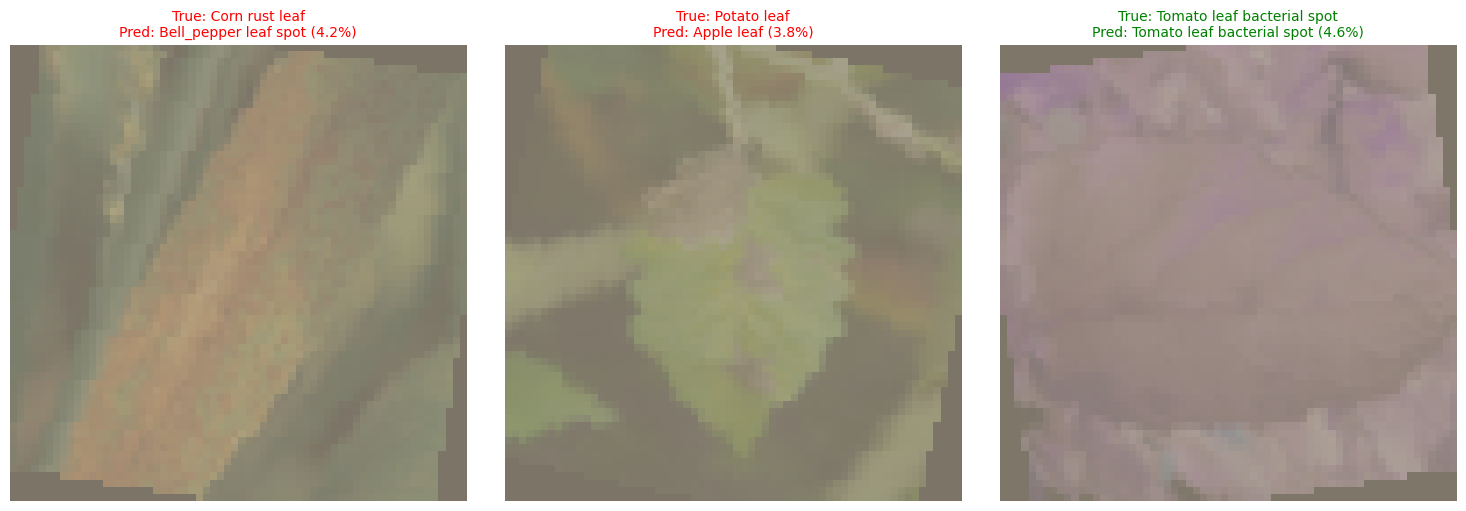

In [40]:
def plot_three_predictions(model, dataset, class_names_list, device):
    model.eval()

    # Create a layout with 1 row and 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # ImageNet stats for exact color restoration
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    for i in range(3):
        random_idx = random.randint(0, len(dataset) - 1)
        image_tensor, true_label = dataset[random_idx]

        with torch.inference_mode():
            pred_logits = model(image_tensor.unsqueeze(0).to(device))
            pred_prob = torch.softmax(pred_logits, dim=1)
            pred_label = torch.argmax(pred_prob, dim=1).item()

        # Fix color channel alignment and denormalize
        img_to_show = image_tensor.permute(1, 2, 0).cpu().numpy()
        img_to_show = std * img_to_show + mean
        img_to_show = np.clip(img_to_show, 0, 1)

        # Plot on the specific subplot axis
        axes[i].imshow(img_to_show)
        axes[i].axis("off")

        title_color = "green" if pred_label == true_label else "red"
        true_name = class_names_list[true_label]
        pred_name = class_names_list[pred_label]

        axes[i].set_title(
            f"True: {true_name}\nPred: {pred_name} ({pred_prob[0][pred_label].item()*100:.1f}%)",
            color=title_color,
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()



plot_three_predictions(
    model=model_efficientnet,
    dataset=doc_test_data,
    class_names_list=find_class_names_doc(),
    device=device,
)

In [ ]:
#model_save_path = "models/efficientnet_b0_plant_disease_38_class.pth"
#torch.save(model_efficientnet.state_dict(), model_save_path)

#print(f"🎉 Model weights successfully saved to: {model_save_path}")

In [20]:
def evaluate_on_test_data(model, test_dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_logits)

        test_loss = test_loss / len(test_dataloader)
    test_acc = test_acc / len(test_dataloader)

    print("=== FINAL TEST DATASET RESULTS ===")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

In [3]:
model_efficientnet = torchvision.models.efficientnet_b0(weights=None).to(device)
model_efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), nn.Linear(in_features=1280, out_features=38)
).to(device)

# 2. Load your saved 30-epoch weights back in!
weights_path = "models/efficientnet_b0_plant_disease_38_class.pth"
model_efficientnet.load_state_dict(torch.load(weights_path, map_location=device))
print("🎉 Successfully loaded your trained model weights!")

🎉 Successfully loaded your trained model weights!


In [21]:
doc_test_data.transform = valid_transforms
doc_test_dataloader = DataLoader(doc_test_data, batch_size=32, shuffle=False)
evaluate_on_test_data(
    model=model_efficientnet,
    test_dataloader=doc_test_dataloader,
    loss_fn=loss_fn,
    device=device,
)

=== FINAL TEST DATASET RESULTS ===
Test Loss: 1.6784
Test Accuracy: 49.14%


In [27]:
def calculate_accuracy_confidence_interval(
    model, test_dataloader, device, confidence_level=0.95
):
    model.eval()

    total_samples = 0
    correct_predictions = 0

    with torch.inference_mode():
        for X, y in test_dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = logits.argmax(dim=1)

            correct_predictions += (preds == y).sum().item()
            total_samples += len(y)

    p_hat = correct_predictions / total_samples

    z_table = {0.90: 1.645, 0.95: 1.96, 0.99: 2.576}
    z = z_table.get(confidence_level, 1.96)

    standard_error = math.sqrt((p_hat * (1 - p_hat)) / total_samples)
    margin_of_error = z * standard_error

    lower_bound = p_hat - margin_of_error
    upper_bound = p_hat + margin_of_error
    print(f"=== {confidence_level * 100:.0f}% ACCURACY CONFIDENCE INTERVAL REPORT ===")
    print(f"Total Test Samples (n): {total_samples}")
    print(f"Correct Guesses: {correct_predictions} / {total_samples}")
    print(f"Sample Accuracy (p-hat): {p_hat * 100:.2f}%")
    print(f"Margin of Error: \u00b1{margin_of_error * 100:.2f}%")
    print(
        f"True Performance Interval: [{lower_bound * 100:.2f}%, {upper_bound * 100:.2f}%]"
    )
    print("\nInterpretation:")
    print(
        f"We are {confidence_level * 100:.0f}% confident that the true, underlying accuracy"
    )
    print(
        f"of this model on entirely new plant data lies between {lower_bound * 100:.2f}% and {upper_bound * 100:.2f}%."
    )


calculate_accuracy_confidence_interval(
    model=model_efficientnet, test_dataloader=doc_test_dataloader, device=device
)

=== 95% ACCURACY CONFIDENCE INTERVAL REPORT ===
Total Test Samples (n): 239
Correct Guesses: 119 / 239
Sample Accuracy (p-hat): 49.79%
Margin of Error: ±6.34%
True Performance Interval: [43.45%, 56.13%]

Interpretation:
We are 95% confident that the true, underlying accuracy
of this model on entirely new plant data lies between 43.45% and 56.13%.


 Found class names in YAML file: data.yaml
Successfully loaded 30 classes!


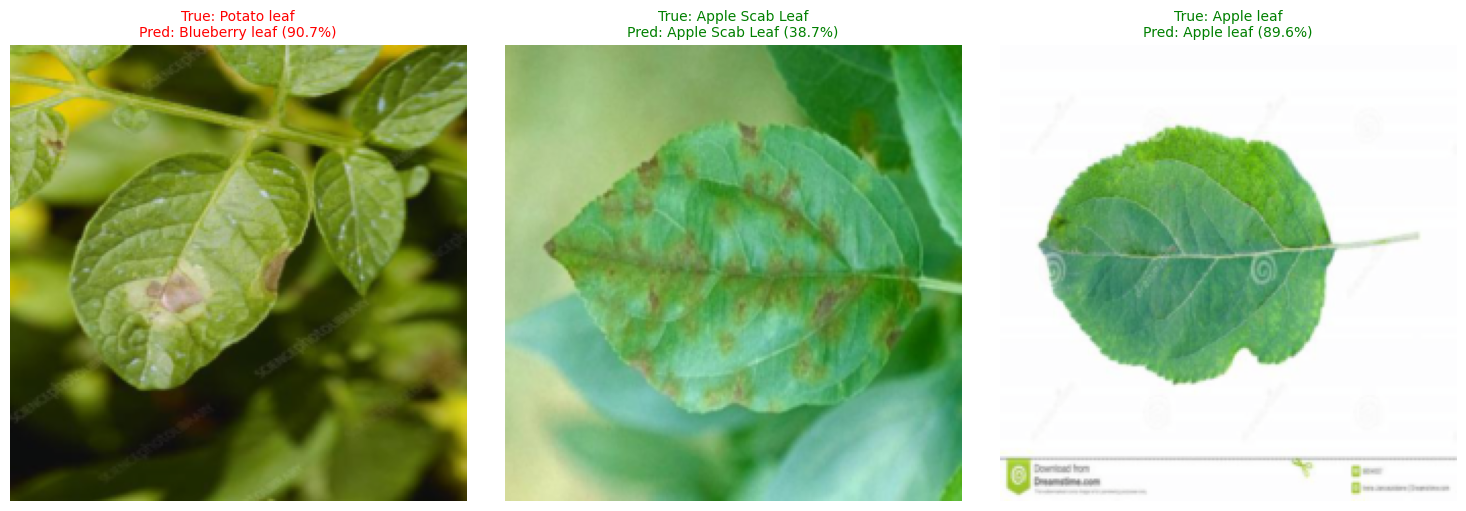

In [61]:
plot_three_predictions(
    model=model_efficientnet,
    dataset=doc_test_data,
    class_names_list=find_class_names_doc(),
    device=device,
)

# Species identification

## Getting the data 

In [ ]:
# os.environ["KAGGLEHUB_CACHE"] = str(Path("").absolute() / "leafsnap_data")

# 2. Run the download (it will go straight into the folder above)
# path = kagglehub.dataset_download("vandat2601/leafsnap-processed")
# print("Downloaded straight to:", path)

# 3. See what folders are inside it
# print("\nContents of your local folder:")
# print(os.listdir(path))
#!pip install tqdm

In [ ]:
images, labels = next(iter(train_dataloader))

# 2. Set up a grid to plot
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i + 1)

    # PyTorch images are [Channels, Height, Width], but matplotlib needs [Height, Width, Channels]
    # We use .permute() to swap the dimensions
    img = images[i].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.show()